# Duplication Analysis

This notebook analyzes duplicate transcriptions in the Bills of Mortality dataset to estimate the overall accuracy of our transcribed data. It does not differentiate between data that was mistranscribed and data that was printed differently in two separate copies of the same bill of mortality; both are considered "inaccurate" data.

## Set Up

We begin by importing libraries, reading in the data from the project GitHub, and creating a dataframe.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

# Set up plotting
plt.style.use('default')
sns.set_palette('husl')
%matplotlib inline

In [2]:
!wget https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/all_bills.csv

--2025-11-18 14:55:24--  https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/all_bills.csv
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 134610408 (128M) [text/plain]
Saving to: ‘all_bills.csv’

all_bills.csv       100%[===================>] 128.37M  25.3MB/s    in 5.1s    

2025-11-18 14:55:30 (25.1 MB/s) - ‘all_bills.csv’ saved [134610408/134610408]



In [3]:
!wget https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/weeks.csv

--2025-11-18 14:55:30--  https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/weeks.csv
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 515592 (504K) [text/plain]
Saving to: ‘weeks.csv’

weeks.csv           100%[===================>] 503.51K  --.-KB/s    in 0.1s    

2025-11-18 14:55:31 (4.27 MB/s) - ‘weeks.csv’ saved [515592/515592]



In [4]:
!wget https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/parishes.csv

--2025-11-18 14:55:31--  https://media.githubusercontent.com/media/chnm/bom/refs/heads/main/bom-processing/scripts/bompy/data/parishes.csv
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11006 (11K) [text/plain]
Saving to: ‘parishes.csv’

parishes.csv        100%[===================>]  10.75K  --.-KB/s    in 0.001s  

2025-11-18 14:55:31 (9.93 MB/s) - ‘parishes.csv’ saved [11006/11006]



In [5]:
# Load the data we need:
all_bills = pd.read_csv(Path('all_bills.csv'))
weeks = pd.read_csv(Path('weeks.csv'))
parishes = pd.read_csv(Path('parishes.csv'))

# Merge the two dataframes on 'joinid', bringing in only selected columns from weeks
bills = all_bills.merge(
    weeks[['joinid', 'week_number', 'start_day', 'end_day', 'start_month', 'end_month']],
    on='joinid',
    how='left'
)

# Convert start_day and end_day to integer (if not null)
bills['start_day'] = bills['start_day'].astype('Int64')
bills['end_day'] = bills['end_day'].astype('Int64')

bills.head()

,parish_id,count_type,count,year,joinid,bill_type,missing,illegible,source,unique_identifier,week_number,start_day,end_day,start_month,end_month
0,24,buried,0,1662,1662121616621223,weekly,True,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1662-01-recto,1,16,23,December,December
1,24,plague,0,1662,1662121616621223,weekly,True,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1662-01-recto,1,16,23,December,December
2,1,buried,1,1662,1662121616621223,weekly,False,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1662-01-recto,1,16,23,December,December
3,1,plague,0,1662,1662121616621223,weekly,True,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1662-01-recto,1,16,23,December,December
4,2,buried,1,1662,1662121616621223,weekly,False,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1662-01-recto,1,16,23,December,December


## Duplicate Identification

Our next step is to identify whether there are duplicate transcriptions of bills from multiple sources (`source`) in our entire dataset. We start by generating a unique identifier for each week to use as our duplication key.

We are using the following fields:

- `parish_id`: Identifies the specific parish the record belongs to.
- `count_type`: Specifies whether the count is for burials or plague deaths.
- `joinid`: Represents a unique identifier for the week, combining year, start day, and end day in a consistent format.

Together, these fields pinpoint a unique weekly count for a specific parish. If two rows have the same combination of these values but come from different sources, it strongly suggests a potential duplicate transcription: two or more (presumably identical) copies of the bill from that week survive and were transcribed. In this case, we are chosing to not use the `count` in the event that it was mis-transcribed or misprinted.

Using this key allows us to identify instances where the same information for a given parish and week appears multiple times in the dataset.

In [6]:
# Create unique identifier ("duplication key")

bills['duplication_key'] = (
    bills['parish_id'].astype(str) + '-' +
    bills['count_type'].astype(str) + '-' +
    bills['joinid'].astype(str)
)

bills.head(10) # check the duplication keys

,parish_id,count_type,count,year,joinid,bill_type,missing,illegible,source,unique_identifier,week_number,start_day,end_day,start_month,end_month,duplication_key
0,24,buried,0,1662,1662121616621223,weekly,True,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1662-01-recto,1,16,23,December,December,24-buried-1662121616621223
1,24,plague,0,1662,1662121616621223,weekly,True,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1662-01-recto,1,16,23,December,December,24-plague-1662121616621223
2,1,buried,1,1662,1662121616621223,weekly,False,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1662-01-recto,1,16,23,December,December,1-buried-1662121616621223
3,1,plague,0,1662,1662121616621223,weekly,True,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1662-01-recto,1,16,23,December,December,1-plague-1662121616621223
4,2,buried,1,1662,1662121616621223,weekly,False,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1662-01-recto,1,16,23,December,December,2-buried-1662121616621223
5,2,plague,0,1662,1662121616621223,weekly,True,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1662-01-recto,1,16,23,December,December,2-plague-1662121616621223
6,3,buried,1,1662,1662121616621223,weekly,False,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1662-01-recto,1,16,23,December,December,3-buried-1662121616621223
7,3,plague,0,1662,1662121616621223,weekly,True,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1662-01-recto,1,16,23,December,December,3-plague-1662121616621223
8,4,buried,0,1662,1662121616621223,weekly,True,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1662-01-recto,1,16,23,December,December,4-buried-1662121616621223
9,4,plague,0,1662,1662121616621223,weekly,True,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1662-01-recto,1,16,23,December,December,4-plague-1662121616621223


In [7]:
# Filer the dataframe to just include duplicates and create a new dataframe based on that result

dup_mask = bills.duplicated(subset='duplication_key', keep=False)
duplicates = bills[dup_mask]

duplicates.head(20)


,parish_id,count_type,count,year,joinid,bill_type,missing,illegible,source,unique_identifier,week_number,start_day,end_day,start_month,end_month,duplication_key
4658,24,buried,0,1663,1663061616630623,weekly,True,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1663-27-recto,27,16,23,June,June,24-buried-1663061616630623
4659,24,buried,0,1663,1663061616630623,weekly,True,False,2025-11-03-BodleianV3-weeklybills-parishes.csv,Bodleian-1663-27-recto,27,16,23,June,June,24-buried-1663061616630623
4660,24,plague,0,1663,1663061616630623,weekly,True,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1663-27-recto,27,16,23,June,June,24-plague-1663061616630623
4661,24,plague,0,1663,1663061616630623,weekly,True,False,2025-11-03-BodleianV3-weeklybills-parishes.csv,Bodleian-1663-27-recto,27,16,23,June,June,24-plague-1663061616630623
4662,1,buried,0,1663,1663061616630623,weekly,True,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1663-27-recto,27,16,23,June,June,1-buried-1663061616630623
4663,1,buried,0,1663,1663061616630623,weekly,True,False,2025-11-03-BodleianV3-weeklybills-parishes.csv,Bodleian-1663-27-recto,27,16,23,June,June,1-buried-1663061616630623
4664,1,plague,0,1663,1663061616630623,weekly,True,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1663-27-recto,27,16,23,June,June,1-plague-1663061616630623
4665,1,plague,0,1663,1663061616630623,weekly,True,False,2025-11-03-BodleianV3-weeklybills-parishes.csv,Bodleian-1663-27-recto,27,16,23,June,June,1-plague-1663061616630623
4666,2,buried,0,1663,1663061616630623,weekly,True,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1663-27-recto,27,16,23,June,June,2-buried-1663061616630623
4667,2,buried,0,1663,1663061616630623,weekly,True,False,2025-11-03-BodleianV3-weeklybills-parishes.csv,Bodleian-1663-27-recto,27,16,23,June,June,2-buried-1663061616630623


Each duplicate bill contains entries for multiple parishes and multiple count types per parish. We can determine the number of duplicate bills by filtering to just one parish (`parish_id = 1`) and one count type (`count_type = buried`), which occur once per bill.

In [8]:
# Create a new dataframe that filters the data to just parish_id 1 and count_type buried:

bills_filtered = duplicates[
    (duplicates['parish_id'] == 1) &
    (duplicates['count_type'] == 'buried') &
    (duplicates['week_number'] < 55)
]
bills_filtered.sort_values(['year', 'week_number']).head(10)

,parish_id,count_type,count,year,joinid,bill_type,missing,illegible,source,unique_identifier,week_number,start_day,end_day,start_month,end_month,duplication_key
4662,1,buried,0,1663,1663061616630623,weekly,True,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1663-27-recto,27,16,23,June,June,1-buried-1663061616630623
4663,1,buried,0,1663,1663061616630623,weekly,True,False,2025-11-03-BodleianV3-weeklybills-parishes.csv,Bodleian-1663-27-recto,27,16,23,June,June,1-buried-1663061616630623
5204,1,buried,1,1663,1663062316630630,weekly,False,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1663-28-recto,28,23,30,June,June,1-buried-1663062316630630
5205,1,buried,1,1663,1663062316630630,weekly,False,False,2025-11-03-BodleianV3-weeklybills-parishes.csv,Bodleian-1663-28-recto,28,23,30,June,June,1-buried-1663062316630630
5746,1,buried,2,1663,1663063016630707,weekly,False,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1663-29-recto,29,30,7,June,July,1-buried-1663063016630707
5747,1,buried,2,1663,1663063016630707,weekly,False,False,2025-11-03-BodleianV3-weeklybills-parishes.csv,Bodleian-1663-29-recto,29,30,7,June,July,1-buried-1663063016630707
6288,1,buried,1,1663,1663070716630714,weekly,False,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1663-30-recto,30,7,14,July,July,1-buried-1663070716630714
6289,1,buried,1,1663,1663070716630714,weekly,False,False,2025-11-03-BodleianV3-weeklybills-parishes.csv,Bodleian-1663-30-recto,30,7,14,July,July,1-buried-1663070716630714
6830,1,buried,1,1663,1663071416630721,weekly,False,False,2025-11-01-QC-weeklybills-parishes.csv,QC-1663-31-recto,31,14,21,July,July,1-buried-1663071416630721
6831,1,buried,1,1663,1663071416630721,weekly,False,False,2025-11-03-BodleianV3-weeklybills-parishes.csv,Bodleian-1663-31-recto,31,14,21,July,July,1-buried-1663071416630721


In [9]:
# Count the number of duplicate bills

print(len(bills_filtered)) # should be in the 300s!

338


The following legacy code was from when we exported and visualized the list of duplicates for manual inspection to confirm we achieved expected/plausible results based on what we know of the original dataset construction.

In [10]:
#duplicates.to_excel('bills_filtered.xlsx', index=False, sheet_name='duplicates')

In [11]:
#duplicates.to_excel('duplicates_check_all.xlsx', index=False, sheet_name='duplicates')

We counted and visualized the duplicate bills several ways to better understand which parts of the dataset contained duplicates.

In [12]:
# Count and display the number of duplicates from each source

source_counts = bills_filtered['source'].value_counts()

print("Count of duplicate entries by source:")
print(source_counts)

Count of duplicate entries by source:
source
2025-11-03-BodleianV3-weeklybills-parishes.csv            130
2025-10-30-BLV2-weeklybills-parishes.csv                   59
2025-11-01-QC-weeklybills-parishes.csv                     54
2025-11-01-BLV1-weeklybills-parishes.csv                   43
2025-11-01-1669-1670-Wellcome-weeklybills-parishes.csv     43
2025-10-31-BL1877.e.7.V1PostFire-minus3foldbill.csv         5
2025-10-29-BLV1-1673-1674-weeklybills-parishes.csv          4
Name: count, dtype: int64


In [13]:
# Write the duplicate bills to a CSV for use in the mathematical accuracy notebook

bills_filtered.to_csv('duplicate_bills.csv', index=False)

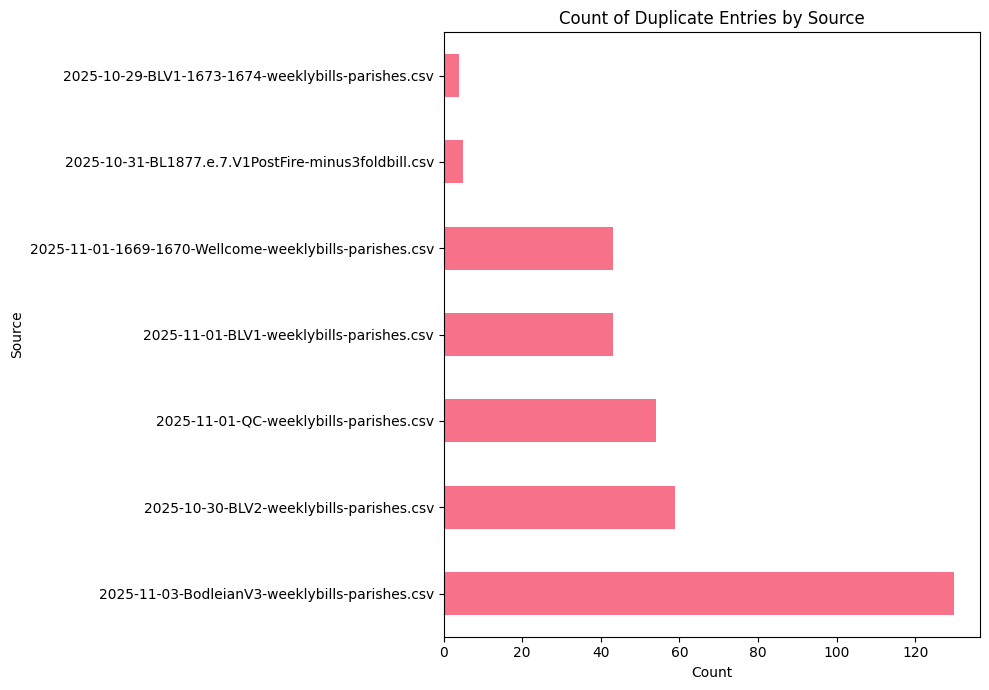

In [14]:
# Visualize the count of duplicates by source

plt.figure(figsize=(10, 7)) # Slightly reduced figure size for compactness
source_counts.plot(kind='barh') # Removed the colormap, using default colors
plt.title('Count of Duplicate Entries by Source')
plt.xlabel('Count')
plt.ylabel('Source')
plt.tight_layout()
plt.show()

In [15]:
# Check the range of years

year_counts = bills_filtered['year'].value_counts()

print("Count of unique years in duplicates")
print(year_counts.sort_index())

Count of unique years in duplicates
year
1663    28
1665    40
1666    56
1669    82
1670     4
1672     2
1674    10
1675    30
1676    74
1677    12
Name: count, dtype: int64


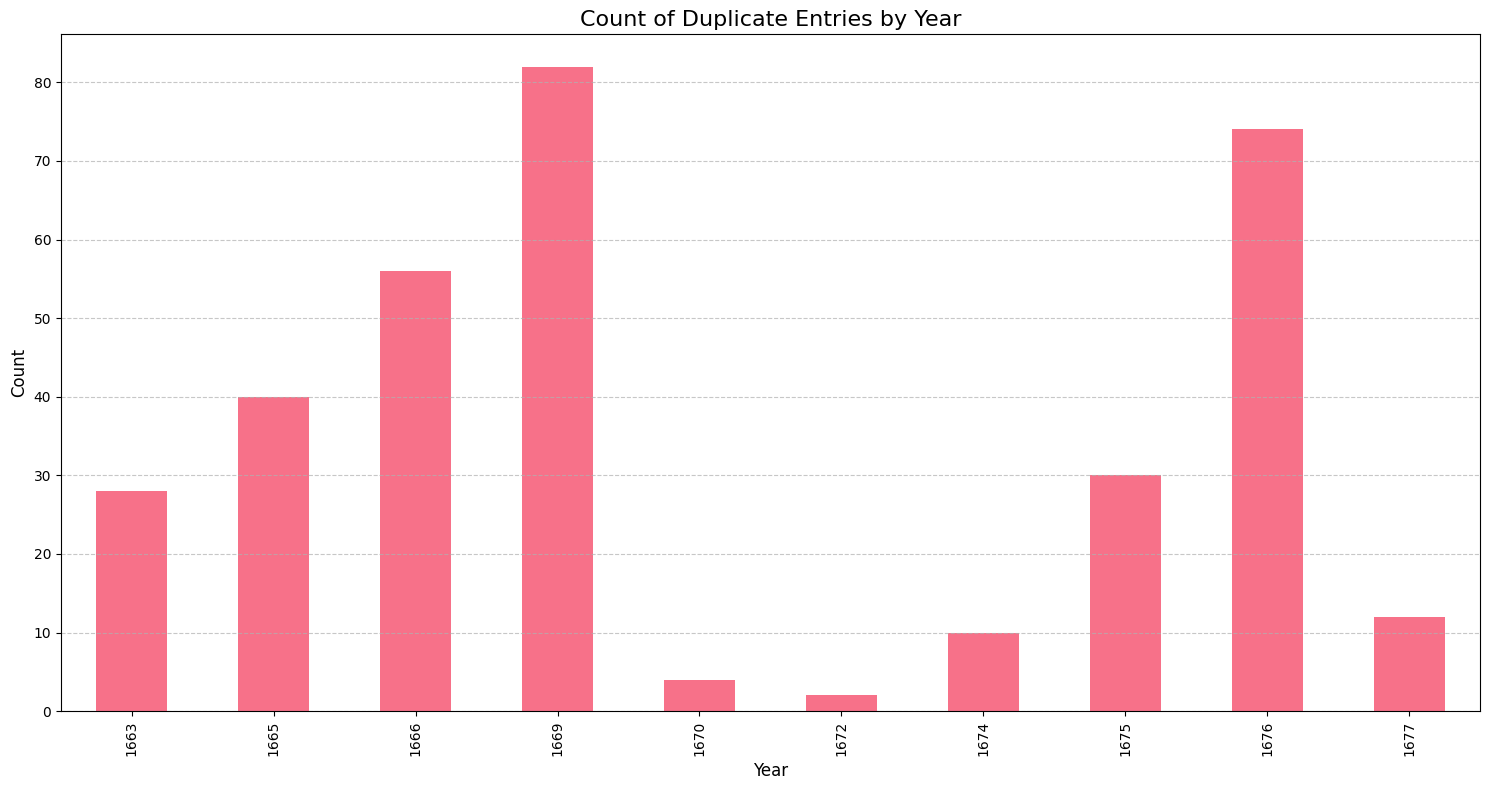

In [16]:
# For the above data year_counts we create a bar chart to visualize our data

plt.figure(figsize=(15, 8)) # Increased figure size for better readability
year_counts.sort_index().plot(kind='bar')
plt.title('Count of Duplicate Entries by Year', fontsize=16) # Larger title font size
plt.xlabel('Year', fontsize=12) # Larger xlabel font size
plt.ylabel('Count', fontsize=12) # Larger ylabel font size
plt.xticks(rotation=90, ha='center', fontsize=10) # Rotate x-axis labels for better readability
plt.yticks(fontsize=10) # Larger yticks font size
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a horizontal grid for easier reading
plt.tight_layout()
plt.show()

## Duplicate Accuracy

Our next step is to check if duplicate data is internally consistent. That is, are duplicate transcriptions of data for the same parish, count type, and week identical?

In [17]:
# Create a list of unique weeks

unique_weeks = bills_filtered['joinid'].unique()
print(f"Number of unique weeks = {len(unique_weeks)}")
print(unique_weeks)

Number of unique weeks = 164
[1663061616630623 1663062316630630 1663063016630707 1663070716630714
 1663071416630721 1663072116630728 1663072816630804 1663080416630811
 1663081116630818 1663081816630825 1663082516630901 1663090116630908
 1663090816630915 1663091516630922 1665010916650116 1665011616650123
 1665012316650130 1665013016650206 1665020616650213 1665021316650220
 1665022016650227 1665022716650306 1665030616650313 1665031316650320
 1665032816650404 1665040416650411 1666032016660327 1666032716660403
 1666040316660410 1666041016660417 1666041716660424 1666042416660501
 1666050116660508 1666050816660515 1666051516660522 1666052216660529
 1666052916660605 1666060516660612 1666061216660619 1666061916660626
 1666062616660703 1666070316660710 1666071016660717 1666071716660724
 1666072416660731 1666073116660807 1666080716660814 1666081416660821
 1666082116660828 1666091816660925 1666092516661002 1666100216661009
 1666100916661016 1666101616661023 1665121916651226 1665122616650102
 1665

In [18]:
# Create a list of unique duplication keys

unique_duplication_keys = duplicates['duplication_key'].unique()
matching_data = 0
mismatched_data = 0

# For each unique duplication key, check if counts match

for key in unique_duplication_keys:
    key_data = duplicates[duplicates['duplication_key'] == key]
    count_matches = key_data['count'].nunique() == 1
    if not count_matches:
      mismatched_data = mismatched_data + 1
      print(f"Key: {key}")
    else:
      matching_data = matching_data + 1

Key: 119-buried-1663062316630630
Key: 120-buried-1663062316630630
Key: 140-buried-1663081116630818
Key: 23-buried-1663081116630818
Key: 22-buried-1663081116630818
Key: 156-buried-1663081116630818
Key: 152-buried-1663090116630908
Key: 104-buried-1663091516630922
Key: 43-buried-1665010916650116
Key: 97-buried-1665010916650116
Key: 71-buried-1665011616650123
Key: 111-buried-1665021316650220
Key: 107-buried-1665021316650220
Key: 72-buried-1665022016650227
Key: 111-buried-1665030616650313
Key: 111-plague-1665030616650313
Key: 107-buried-1665030616650313
Key: 107-plague-1665030616650313
Key: 44-buried-1665032816650404
Key: 101-buried-1665040416650411
Key: 97-buried-1665040416650411
Key: 82-buried-1666041016660417
Key: 30-plague-1666050816660515
Key: 31-plague-1666050816660515
Key: 52-buried-1666051516660522
Key: 8-buried-1666061916660626
Key: 88-buried-1666061916660626
Key: 71-buried-1666072416660731
Key: 128-buried-1666073116660807
Key: 25-buried-1666100916661016
Key: 68-buried-166610161666

In [19]:
# Print results

print(f"Individual data matches = {matching_data}")
print(f"Individual data mis-matches = {mismatched_data}")
print("Percent data matches = " + str((matching_data / (matching_data + mismatched_data)) * 100))

Individual data matches = 43815
Individual data mis-matches = 151
Percent data matches = 99.65655279079289


## Illegible Data

Our final step is to remove records marked as illegible and re-analyze to determine how illegible data impacted our original duplicateion analysis.

In [20]:
# Filter out illegible records

bills_legible = duplicates[duplicates['illegible'] == False].copy()

print(f"Number of rows in entire dataset = {len(bills)}")
print(f"Number of rows in duplicate bills = {len(duplicates)}")
print(f"Number of legible rows in duplicate bills = {len(bills_legible)}")

Number of rows in entire dataset = 1105580
Number of rows in duplicate bills = 90812
Number of legible rows in duplicate bills = 90742


In [21]:
# Filter out any records that are no longer duplicates

dup_mask2 = bills_legible.duplicated(subset='duplication_key', keep=False)
bills_legible_duplicates = bills_legible[dup_mask2]

print(f"Number of legible rows that are still duplicates = {len(bills_legible_duplicates)}")

Number of legible rows that are still duplicates = 90692


In [22]:
# Repeat above but for bills_legibile_duplicates instead of duplicates

unique_duplication_keys_legible = bills_legible_duplicates['duplication_key'].unique()
matching_data_legible = 0
mismatched_data_legible = 0

for key in unique_duplication_keys_legible:
    key_data_legible = bills_legible_duplicates[bills_legible_duplicates['duplication_key'] == key]
    count_matches_legible = key_data_legible['count'].nunique() == 1
    if not count_matches_legible:
      mismatched_data_legible = mismatched_data_legible + 1
      print(f"Key: {key}")
    else:
      matching_data_legible = matching_data_legible + 1

Key: 119-buried-1663062316630630
Key: 120-buried-1663062316630630
Key: 140-buried-1663081116630818
Key: 23-buried-1663081116630818
Key: 22-buried-1663081116630818
Key: 156-buried-1663081116630818
Key: 152-buried-1663090116630908
Key: 104-buried-1663091516630922
Key: 43-buried-1665010916650116
Key: 97-buried-1665010916650116
Key: 71-buried-1665011616650123
Key: 111-buried-1665021316650220
Key: 107-buried-1665021316650220
Key: 111-buried-1665030616650313
Key: 111-plague-1665030616650313
Key: 107-buried-1665030616650313
Key: 107-plague-1665030616650313
Key: 44-buried-1665032816650404
Key: 101-buried-1665040416650411
Key: 97-buried-1665040416650411
Key: 30-plague-1666050816660515
Key: 31-plague-1666050816660515
Key: 52-buried-1666051516660522
Key: 8-buried-1666061916660626
Key: 88-buried-1666061916660626
Key: 71-buried-1666072416660731
Key: 25-buried-1666100916661016
Key: 68-buried-1666101616661023
Key: 22-buried-1666101616661023
Key: 97-buried-1666101616661023
Key: 52-buried-1665121916651

In [23]:
# Print results

print("Individual data matches = " + str(matching_data_legible))
print("Individual data mis-matches = " + str(mismatched_data_legible))
print("Percent data matches = " + str((matching_data_legible / (matching_data_legible + mismatched_data_legible)) * 100))

print("Number of mis-matched data removed as illegible = " + str(mismatched_data-mismatched_data_legible))
print("Percent of mis-matched data that was marked/removed as illegible = " + str((mismatched_data-mismatched_data_legible)/mismatched_data * 100))

Individual data matches = 43778
Individual data mis-matches = 137
Percent data matches = 99.68803370146875
Number of mis-matched data removed as illegible = 14
Percent of mis-matched data that was marked/removed as illegible = 9.271523178807946


In [24]:
bills_legible_duplicates.to_excel('bills_legible_duplicates.xlsx', index=False, sheet_name='duplicates')